## K-means clustering

In [200]:
import logging
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Logger instellen

In [201]:
#
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("clustering_logboek.txt", mode="w", encoding="utf-8"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger(__name__)
logger.info("Logger gestart.")

2026-04-13 17:56:44,856 - INFO - Logger gestart.


### Dataset inlezen

In [202]:
df = pd.read_excel("AmesHousing.xlsx", sheet_name="AmesHousing")
logger.info(f"Bestand succesvol ingelezen ({df.shape[0]} rijen, {df.shape[1]} kolommen).")
df.head()

2026-04-13 17:56:45,273 - INFO - Bestand succesvol ingelezen (2930 rijen, 12 kolommen).


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [203]:
df.dtypes

ID                 int64
SalePrice          int64
Garage               str
Overall Qual       int64
Gr Liv Area        int64
Total Bsmt SF    float64
Lot Area           int64
Year Built         int64
Full Bath          int64
Bedroom AbvGr      int64
Neighborhood         str
House Style          str
dtype: object

### Keuze van top 3 features

Ik kies Overall Qual, Gr Liv Area en Neighborhood als features voor clustering.

- Overall Qual: algemene kwaliteit van het huis
- Gr Liv Area: woonoppervlakte
- Neighborhood: wijk van het huis, dit is de categorische feature

Deze features zijn geschikt, omdat ze de kwaliteit, grootte en ligging van huizen beschrijven.

In [ ]:
data_dictionary = pd.read_excel("AmesHousing.xlsx", sheet_name="Data Dictionary")
gekozen_features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]

# Laat in de Data Dictionary alleen de gekozen features zien
uitleg_features = data_dictionary[data_dictionary["Variabele"].isin(gekozen_features)]

logger.info(f"Gekozen top 3 features voor clustering: {gekozen_features}")
uitleg_features

### Data prepareren

We maken eerst een DataFrame met de gekozen features.
Daarna vullen we missende waarden op, omdat K-means niet met lege waarden kan werken.
Tot slot zetten we de categorische feature Neighborhood om naar dummies: aparte 0/1-kolommen per wijk.

In [193]:
data_stap4 = df[gekozen_features].copy()
data_stap4 = data_stap4.fillna(0)

# Zet Neighborhood om naar 0/1-kolommen
data_stap4_encoded = pd.get_dummies(data_stap4, columns=["Neighborhood"])

logger.info(f"One-hot encoding uitgevoerd: {data_stap4_encoded.shape}")
data_stap4_encoded.head()

2026-04-13 17:53:18,734 - INFO - One-hot encoding uitgevoerd: (2930, 30)


,Overall Qual,Gr Liv Area,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,896,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,1329,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,2110,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,1629,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Eerste KMeans-model

Bij K-means is schalen handig, omdat grote waarden anders meer invloed hebben op de afstandsberekening.
Daarom gebruiken we StandardScaler().

Daarna bekijken we met help(KMeans) welke hyperparameters je kunt instellen.

In [194]:
scaler = StandardScaler()
data_stap5_scaled = scaler.fit_transform(data_stap4_encoded)
# fit_transform() berekent eerst de schaal van de data
# en schaalt de data daarna meteen om.

logger.info("Data geschaald met StandardScaler.")

2026-04-13 17:53:19,044 - INFO - Data geschaald met StandardScaler.


In [195]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

### Eerste model

Voor de eerste run kies ik:
- n_clusters = 4 -> 28 elleboog methode
- random_state = 42
- n_init = 10

n_clusters bepaalt het aantal clusters.
Met n_init probeert K-means meerdere beginpunten en kiest het de beste oplossing.

In [196]:
kmeans_1 = KMeans(n_clusters=28, random_state=42, n_init=10)

# Laat het model de huizen in 4 clusters verdelen
labels_1 = kmeans_1.fit_predict(data_stap5_scaled)
# fit_predict() traint het model en geeft meteen per rij het cluster terug

# Voeg de cluster labels toe aan de data
resultaat_1 = data_stap4.copy()
resultaat_1["Cluster"] = labels_1

logger.info("Eerste KMeans-model getraind: n_clusters=4, random_state=42, n_init=10")
resultaat_1.head()

2026-04-13 17:53:19,670 - INFO - Eerste KMeans-model getraind: n_clusters=4, random_state=42, n_init=10


,Overall Qual,Gr Liv Area,Neighborhood,Cluster
0,6,1656,NAmes,4
1,5,896,NAmes,4
2,6,1329,NAmes,4
3,7,2110,NAmes,4
4,5,1629,Gilbert,0


## Evaluatie van het eerste model

We evalueren het model met:
- Inertia / WSS: laat zien hoe dicht de punten bij hun eigen clustercentrum liggen. Lager is meestal beter.
- Silhouette score: laat zien hoe goed de clusters van elkaar gescheiden zijn. Hoger is meestal beter.

Daarnaast bekijken we hoeveel huizen er in elk cluster zitten.

In [197]:
# Bereken de evaluatiescores van het eerste model

inertia_1 = kmeans_1.inertia_
# inertia telt per huis de afstand tot het midden van zijn cluster op

silhouette_1 = silhouette_score(data_stap5_scaled, labels_1)
# silhouette vergelijkt per huis:
# hoe dicht het bij zijn eigen cluster zit
# en hoe dicht het bij het dichtstbijzijnde andere cluster zit


# Bekijk hoeveel huizen in elk cluster zitten
cluster_verdeling_1 = resultaat_1["Cluster"].value_counts().sort_index()

print(f"Inertia / WSS: {inertia_1:.2f}")
print(f"Silhouette score: {silhouette_1:.4f}")
print("\nVerdeling per cluster:")
print(cluster_verdeling_1)

logger.info(f"Eerste model - inertia: {inertia_1:.2f}, silhouette: {silhouette_1:.4f}")
logger.info(f"Clusterverdeling: {cluster_verdeling_1.to_dict()}")

2026-04-13 17:53:20,024 - INFO - Eerste model - inertia: 3434.21, silhouette: 0.7799
2026-04-13 17:53:20,025 - INFO - Clusterverdeling: {0: 165, 1: 194, 2: 239, 3: 182, 4: 443, 5: 166, 6: 131, 7: 71, 8: 267, 9: 103, 10: 125, 11: 93, 12: 108, 13: 114, 14: 44, 15: 151, 16: 28, 17: 51, 18: 37, 19: 30, 20: 72, 21: 48, 22: 8, 23: 2, 24: 23, 25: 24, 26: 10, 27: 1}


Inertia / WSS: 3434.21
Silhouette score: 0.7799

Verdeling per cluster:
Cluster
0     165
1     194
2     239
3     182
4     443
5     166
6     131
7      71
8     267
9     103
10    125
11     93
12    108
13    114
14     44
15    151
16     28
17     51
18     37
19     30
20     72
21     48
22      8
23      2
24     23
25     24
26     10
27      1
Name: count, dtype: int64


### Korte interpretatie

- Lagere inertia = huizen binnen een cluster lijken meer op elkaar.
- Hogere silhouette score = clusters zijn beter van elkaar gescheiden.

De silhouette score is vaak het handigst om experimenten te vergelijken.

## Extra – Elleboogmethode

Bij de elleboogmethode testen we meerdere waarden voor `k`.
Daarna kijken we waar de lijn van de inertia/WSS begint af te vlakken.
Dat is vaak een goed aantal clusters.

2026-04-13 17:53:21,612 - INFO - Elleboogmethode uitgevoerd voor k = 2 t/m 20


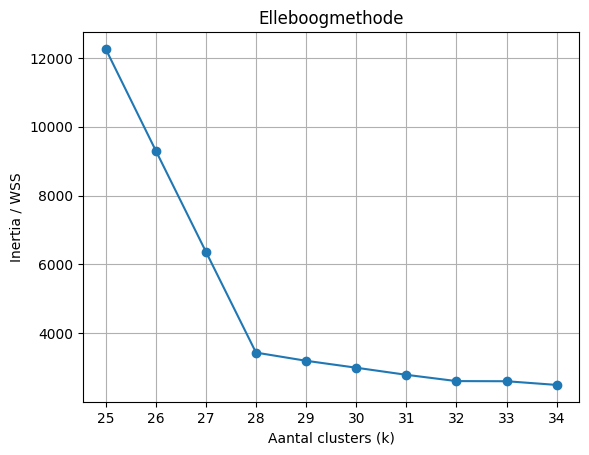

In [198]:
# Bereken de inertia/WSS voor meer waarden van k
k_waardes = range(25, 35)
wss_scores = []

for k in k_waardes:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_stap5_scaled)
    wss_scores.append(kmeans.inertia_)

logger.info("Elleboogmethode uitgevoerd voor k = 2 t/m 20")

plt.plot(list(k_waardes), wss_scores, marker="o")
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Inertia / WSS")
plt.title("Elleboogmethode")
plt.xticks(list(k_waardes))
plt.grid(True)
plt.show()

## Experimenteren

Hieronder staan meerdere experimenten.
Per experiment noteren we:
- gekozen features,
- categorische features,
- of er geschaald is,
- hyperparameters,
- inertia,
- silhouette score.

We bewaren alle werkende experimenten, zodat de ontwikkeling van het model zichtbaar blijft.

In [ ]:
experiment_resultaten = []

experiment_resultaten.append({
    "Experiment": "Initiële run",
    "Features": ", ".join(gekozen_features),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_1, 2),
    "Silhouette score": round(silhouette_1, 4)
})

### Experiment 1 – Zelfde features, maar ander aantal clusters

In [199]:
features_exp1 = ["Overall Qual", "Gr Liv Area", "Neighborhood"]
data_exp1 = df[features_exp1].copy()
data_exp1_encoded = pd.get_dummies(data_exp1, columns=["Neighborhood"])

scaler_exp1 = StandardScaler()
data_exp1_scaled = scaler_exp1.fit_transform(data_exp1_encoded)

kmeans_exp1 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_exp1 = kmeans_exp1.fit_predict(data_exp1_scaled)

inertia_exp1 = kmeans_exp1.inertia_
silhouette_exp1 = silhouette_score(data_exp1_scaled, labels_exp1)

print(f"Inertia / WSS: {inertia_exp1:.2f}")
print(f"Silhouette score: {silhouette_exp1:.4f}")

logger.info("Experiment 1 uitgevoerd: n_clusters=5, random_state=42, n_init=10")
logger.info(f"Experiment 1 - features: {features_exp1}")
logger.info(f"Experiment 1 - inertia: {inertia_exp1:.2f}, silhouette: {silhouette_exp1:.4f}")

experiment_resultaten.append({
    "Experiment": "Experiment 1 - ander aantal clusters",
    "Features": ", ".join(features_exp1),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 5,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp1, 2),
    "Silhouette score": round(silhouette_exp1, 4)
})

2026-04-13 17:56:38,719 - INFO - Experiment 1 uitgevoerd: n_clusters=5, random_state=42, n_init=10
2026-04-13 17:56:38,720 - INFO - Experiment 1 - features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
2026-04-13 17:56:38,721 - INFO - Experiment 1 - inertia: 73747.00, silhouette: 0.1597


Inertia / WSS: 73747.00
Silhouette score: 0.1597


NameError: name 'experiment_resultaten' is not defined

### Experiment 2 – Meer features toevoegen

In [ ]:
# Experiment 2: extra numerieke feature toevoegen
features_exp2 = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Neighborhood"]
data_exp2 = df[features_exp2].copy()
data_exp2 = data_exp2.fillna(0)
data_exp2_encoded = pd.get_dummies(data_exp2, columns=["Neighborhood"])

scaler_exp2 = StandardScaler()
data_exp2_scaled = scaler_exp2.fit_transform(data_exp2_encoded)

kmeans_exp2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_exp2 = kmeans_exp2.fit_predict(data_exp2_scaled)

inertia_exp2 = kmeans_exp2.inertia_
silhouette_exp2 = silhouette_score(data_exp2_scaled, labels_exp2)

print(f"Inertia / WSS: {inertia_exp2:.2f}")
print(f"Silhouette score: {silhouette_exp2:.4f}")

logger.info("Experiment 2 uitgevoerd: n_clusters=4, random_state=42, n_init=10")
logger.info(f"Experiment 2 - features: {features_exp2}")
logger.info(f"Experiment 2 - inertia: {inertia_exp2:.2f}, silhouette: {silhouette_exp2:.4f}")

experiment_resultaten.append({
    "Experiment": "Experiment 2 - extra feature",
    "Features": ", ".join(features_exp2),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp2, 2),
    "Silhouette score": round(silhouette_exp2, 4)
})

### Experiment 3 – Andere categorische feature


In [ ]:
# Experiment 3: andere categorische feature gebruiken
features_exp3 = ["Overall Qual", "Gr Liv Area", "House Style"]
data_exp3 = df[features_exp3].copy()
data_exp3_encoded = pd.get_dummies(data_exp3, columns=["House Style"])

scaler_exp3 = StandardScaler()
data_exp3_scaled = scaler_exp3.fit_transform(data_exp3_encoded)

kmeans_exp3 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_exp3 = kmeans_exp3.fit_predict(data_exp3_scaled)

inertia_exp3 = kmeans_exp3.inertia_
silhouette_exp3 = silhouette_score(data_exp3_scaled, labels_exp3)

print(f"Inertia / WSS: {inertia_exp3:.2f}")
print(f"Silhouette score: {silhouette_exp3:.4f}")

logger.info("Experiment 3 uitgevoerd: n_clusters=4, random_state=42, n_init=10")
logger.info(f"Experiment 3 - features: {features_exp3}")
logger.info(f"Experiment 3 - inertia: {inertia_exp3:.2f}, silhouette: {silhouette_exp3:.4f}")

experiment_resultaten.append({
    "Experiment": "Experiment 3 - andere categorische feature",
    "Features": ", ".join(features_exp3),
    "Categorische feature": "House Style",
    "Geschaald": "Ja",
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp3, 2),
    "Silhouette score": round(silhouette_exp3, 4)
})

### Experiment 4 – Meer features, ander aantal clusters en andere hyperparameter

In [ ]:
# Experiment 4: meer features en ander aantal clusters
features_exp4 = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Year Built", "Neighborhood"]
data_exp4 = df[features_exp4].copy()
data_exp4 = data_exp4.fillna(0)
data_exp4_encoded = pd.get_dummies(data_exp4, columns=["Neighborhood"])

scaler_exp4 = StandardScaler()
data_exp4_scaled = scaler_exp4.fit_transform(data_exp4_encoded)

kmeans_exp4 = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_exp4 = kmeans_exp4.fit_predict(data_exp4_scaled)

inertia_exp4 = kmeans_exp4.inertia_
silhouette_exp4 = silhouette_score(data_exp4_scaled, labels_exp4)

print(f"Inertia / WSS: {inertia_exp4:.2f}")
print(f"Silhouette score: {silhouette_exp4:.4f}")

logger.info("Experiment 4 uitgevoerd: n_clusters=5, random_state=42, n_init=20")
logger.info(f"Experiment 4 - features: {features_exp4}")
logger.info(f"Experiment 4 - inertia: {inertia_exp4:.2f}, silhouette: {silhouette_exp4:.4f}")

experiment_resultaten.append({
    "Experiment": "Experiment 4 - meer features en ander k",
    "Features": ", ".join(features_exp4),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 5,
    "random_state": 42,
    "n_init": 20,
    "Inertia": round(inertia_exp4, 2),
    "Silhouette score": round(silhouette_exp4, 4)
})

### Vergelijking van alle experimenten

Hier zetten we alle resultaten naast elkaar.
Voor de eindkeuze kijk ik vooral naar de **silhouette score** en naar hoe logisch en duidelijk de gebruikte features zijn.

In [ ]:
# Zet alle experimenten in een tabel en sorteer op silhouette score
vergelijking_df = pd.DataFrame(experiment_resultaten)
vergelijking_df = vergelijking_df.sort_values("Silhouette score", ascending=False)

vergelijking_df

In [ ]:
beste_experiment = vergelijking_df.iloc[0]

print("Beste experiment op basis van de silhouette score:")
print(beste_experiment[["Experiment", "Silhouette score", "n_clusters"]])

logger.info(
    f"Beste experiment: {beste_experiment['Experiment']} "
    f"(silhouette score = {beste_experiment['Silhouette score']}, "
    f"n_clusters = {beste_experiment['n_clusters']})"
)

### Korte conclusie

Het beste experiment is het experiment met de hoogste **silhouette score**.
Dat experiment presteert beter dan de initiële run, omdat de clusters daarin duidelijker van elkaar gescheiden zijn.

Bij de verantwoording kun je dus uitleggen:
1. welke eerste keuze je maakte,
2. welk resultaat daaruit kwam,
3. welk nieuw experiment je daarna probeerde,
4. en waarom dat nieuwe experiment beter of juist minder goed werkte.